Comparing the stellar mass values of GAMA catalogue in our sample (see *oursample.ipynb*).

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density
import pandas as pd
from scipy.optimize import curve_fit
import seaborn as sns
sns.set_style('white') # set figure style
from scipy.interpolate import interpn
import scipy.stats as stats
from scipy.optimize import minimize
from pyrolite.plot.density import density

### Reading data

In [2]:
# reading the file to 'data' pandas dataframe
data = pd.read_csv( '../check_sm.txt', delimiter = '\t', low_memory = False )
data.head()

,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,...,log_sm,d_log_sm,fluxscale,log_gama_sm,log_sm_lambdar,d_log_sm_lambdar,fluxscale_lambdar,log_gama_sm_lambdar,sm,log_gama_sm_magphys
0,260,12125210+0117588,J121252.11+011758.9,G,183.217087,1.299673,7.953,0.015,8.868,NaN,...,10.67840,0.104434,1.077330,10.740281,10.67200,0.108565,1.076980,10.733740,26270000000,10.419460
1,1025,14463127+0116286,J144631.24+011629.2,G,221.630325,1.274620,10.528,0.048,10.926,NaN,...,11.08790,0.110348,1.165130,11.183806,11.08410,0.112150,1.255260,11.212366,126100000000,11.100715
2,1656,14441893+0002312,J144418.90+000230.8,G,221.078888,0.042021,11.229,0.071,11.679,NaN,...,10.69100,0.109208,1.254340,10.818947,10.68640,0.119500,0.984636,10.709208,33090000000,10.519697
3,1899,12024266+0157083,J120242.71+015707.2,G,180.677765,1.952326,11.402,0.075,12.060,NaN,...,10.44000,0.113381,0.875903,10.411988,10.41900,0.107483,1.071390,10.478480,28080000000,10.448397
4,2791,08360330+0119469,J083603.32+011947.2,G,129.013763,1.329719,12.066,0.081,12.225,0.023,...,9.83516,0.115833,1.112100,9.910836,9.84532,0.109942,1.118270,9.923399,3542000000,9.549249


How many Inf or NaN data are in the sample?

In [3]:
np.sum(np.isinf(data.log_gama_sm)), np.sum(np.isinf(data.log_gama_sm_lambdar)), np.sum(np.isinf(data.log_gama_sm_magphys))

(0, 0, 0)

In [4]:
np.sum(np.isnan(data.log_gama_sm)), np.sum(np.isnan(data.log_gama_sm_lambdar)), np.sum(np.isnan(data.log_gama_sm_magphys))

(0, 0, 0)

#### Comparing plots

Functions

In [5]:
# for the linear fitting
def linfit( x, a, b ):
    return a*x+b 

In [6]:
def MLE_fit( x, y, guess = np.array( [1,2,2] ) ):
    # MLE function
    # ml modeling and neg LL calculation
    def MLE_Norm(parameters):
        # extract parameters
        const, beta, std_dev = parameters
        # predict the output
        pred = const + beta*x
        # Calculate the log-likelihood for normal distribution
        LL = np.sum(stats.norm.logpdf(y, pred, std_dev))
        # Calculate the negative log-likelihood
        neg_LL = -1*LL
        return neg_LL 

    # minimize arguments: function, intial_guess_of_parameters, method
    return minimize(MLE_Norm, guess, method='Nelder-Mead' ) # 'L-BFGS-B', 'trust-constr'

In [7]:
def compare_plot( sample1, sample2, name1, name2, fsize = (20, 12), fs = 40, fst = 35, size = 5, guess = np.array([1,2,1]) ):
    fig = plt.figure( figsize = (fsize), dpi = 100 )
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    plt.xlabel( '$\log($' + name1 + ' [M$_{\odot}$])', fontsize = fs )
    plt.ylabel( '$\log($' + name2 + ' [M$_{\odot}$])', fontsize = fs )
    plt.xticks( fontsize = fst )
    plt.yticks( fontsize = fst )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)
    plt.rcParams["font.size"] = 30
    plt.xlim( 8, 13 )
    plt.ylim( 8, 13 )
    x = np.linspace( 8, 13, 100 )
    plt.plot(x, x, c = 'k', zorder = 10)
    
    data , x_e, y_e = np.histogram2d( sample1, sample2, bins = 100, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ),
                data, np.vstack([sample1, sample2]).T , method = "splinef2d", bounds_error = False)
    z[np.isnan(z)] = 0
    z[np.where(z <= 0)] = np.min(z[np.where(z > 0)])/10
    col = plt.scatter( sample1, sample2, size, z, vmin = np.nanmin(z), vmax = np.nanmax(z),
                      cmap='viridis' )
    cbar = plt.colorbar(col)
    cbar.ax.set_ylabel('Number density', fontsize = fs)
    cbar.ax.tick_params(labelsize=fs-5)

    # fit with least squares:
    print('Least square method')
    plt.rcParams['agg.path.chunksize'] = 10000
    popt, pcov = curve_fit( linfit, sample1, sample2, p0 = [0.8, 2] )
    print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x + ', popt[1], '$\pm$', np.sqrt(pcov[1,1]) )
    
    # draw the fitted curve:
    eq = 'y = ('+ '{:.2e}'.format( popt[0] ) + '$\pm$' + '{:.2e}'.format( np.sqrt( pcov[0,0] ) ) + ') $\cdot$ x + ('+ '{:.2e}'.format( popt[1] ) + '$\pm$'+'{:.2e}'.format( np.sqrt( pcov[1,1] ) ) + ')'
    plt.plot( x, popt[0] * x + popt[1], lw = 2, ls = '--',
             c = 'purple', label = eq )
    plt.rcParams["font.size"] = 32
    
    # fit with maximum likelihood:
    print('Maximum likelihood method')
    mle_model = MLE_fit(sample1, sample2, guess)
    print(mle_model) 
    
    # draw the fitted curve:
    plt.plot( x, mle_model.x[1] * x + mle_model.x[0], lw = 1.5, ls = '-.',
             c = 'orange', label = 'Maximum likelihood fit' )
    plt.rcParams["font.size"] = 32
    plt.grid();

In [8]:
def compare_plot_contour( sample1, sample2, name1, name2, fname = 'plot', fsize = (20, 12),
                          fs = 40, fst = 35, size = 2, guess = np.array([1,2,1]), xmin = 8, xmax = 13  ):
    fig = plt.figure( figsize = (fsize), dpi = 100 )
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    pd.DataFrame( { "sample1": sample1, "sample2" : sample2 } ).pyroplot.density(ax=ax, contours=[0.95, 0.68], linewidths=[2,4], 
                                                                                 zorder = 10,
                                                                                 label_contours = False, colors = ['green', 'purple'] )
    plt.xlabel( '$\log_{10}($' + name1 + ' [M$_{\odot}$])', fontsize = fs )
    plt.ylabel( '$\log_{10}($' + name2 + ' [M$_{\odot}$])', fontsize = fs )
    plt.xticks( fontsize = fst )
    plt.yticks( fontsize = fst )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)
    plt.rcParams["font.size"] = 30
    plt.xlim( xmin, xmax )
    plt.ylim( xmin, xmax )
    x = np.linspace( xmin, xmax, 100 )
    plt.plot(x, x, c = 'k', zorder = 10)
    plt.scatter( sample1, sample2, 3, 'black' )
    
    # fit with least squares:
    print('Least square method')
    plt.rcParams['agg.path.chunksize'] = 10000
    popt, pcov = curve_fit( linfit, sample1, sample2, p0 = [0.8, 2] )
    print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x + ', popt[1], '$\pm$', np.sqrt(pcov[1,1]) )
    
    # fit with maximum likelihood:
    print('Maximum likelihood method')
    mle_model = MLE_fit(sample1, sample2, guess)
    print(mle_model) 
    
    # draw the fitted curve:
    plt.plot( x, mle_model.x[1] * x + mle_model.x[0], lw = 1.5, ls = '-.', zorder=50,
             c = 'orange' )
    plt.rcParams["font.size"] = 32
    plt.grid()
    plt.savefig( fname, format = 'pdf' )
    return mle_model.x;


Plots

Least square method
y = ( 1.0090588669699072 $\pm$ 0.0016485152539618946 )*x +  -0.08097512250544892 $\pm$ 0.017985677486090684
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -7198.748867649737
             x: [-8.095e-02  1.009e+00  4.611e-02]
           nit: 150
          nfev: 260
 final_simplex: (array([[-8.095e-02,  1.009e+00,  4.611e-02],
                       [-8.104e-02,  1.009e+00,  4.610e-02],
                       [-8.103e-02,  1.009e+00,  4.610e-02],
                       [-8.087e-02,  1.009e+00,  4.610e-02]]), array([-7.199e+03, -7.199e+03, -7.199e+03, -7.199e+03]))


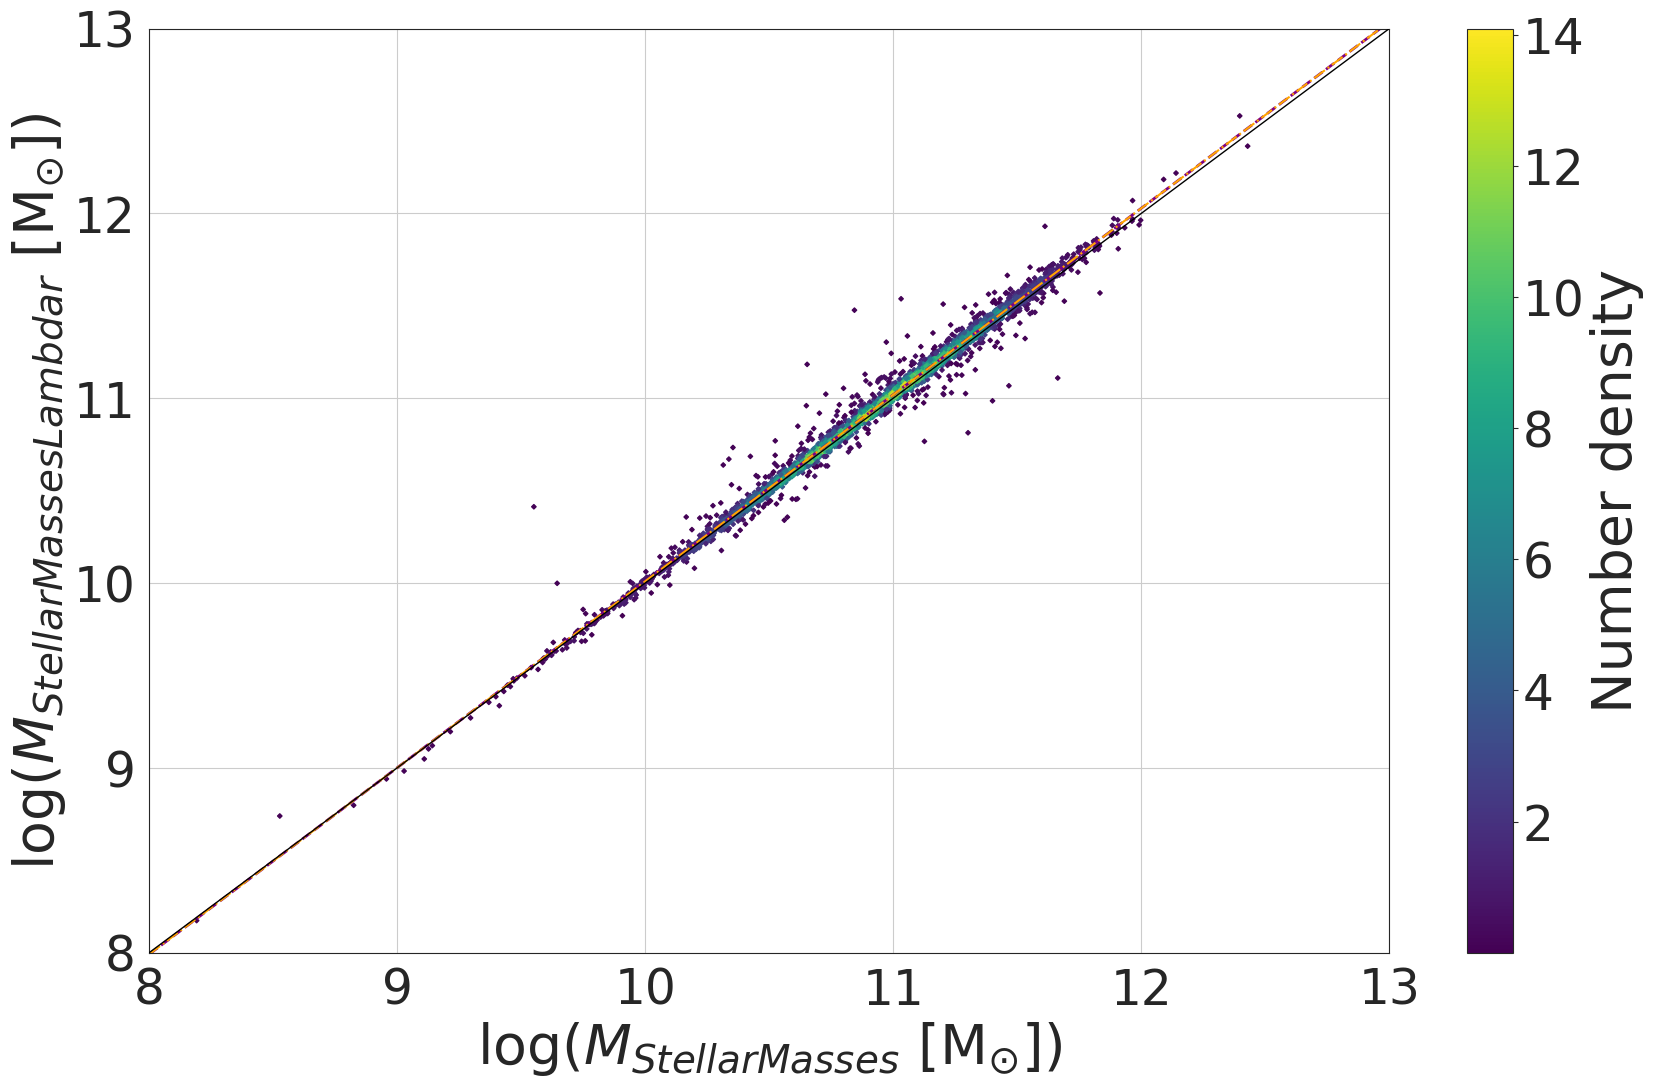

In [9]:
compare_plot( data.log_gama_sm, data.log_gama_sm_lambdar, 
             '$M_{StellarMasses}$', '$M_{StellarMassesLambdar}$' )

Least square method
y = ( 1.0090588669699072 $\pm$ 0.0016485152539618946 )*x +  -0.08097512250544892 $\pm$ 0.017985677486090684
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -7198.748867649737
             x: [-8.095e-02  1.009e+00  4.611e-02]
           nit: 150
          nfev: 260
 final_simplex: (array([[-8.095e-02,  1.009e+00,  4.611e-02],
                       [-8.104e-02,  1.009e+00,  4.610e-02],
                       [-8.103e-02,  1.009e+00,  4.610e-02],
                       [-8.087e-02,  1.009e+00,  4.610e-02]]), array([-7.199e+03, -7.199e+03, -7.199e+03, -7.199e+03]))


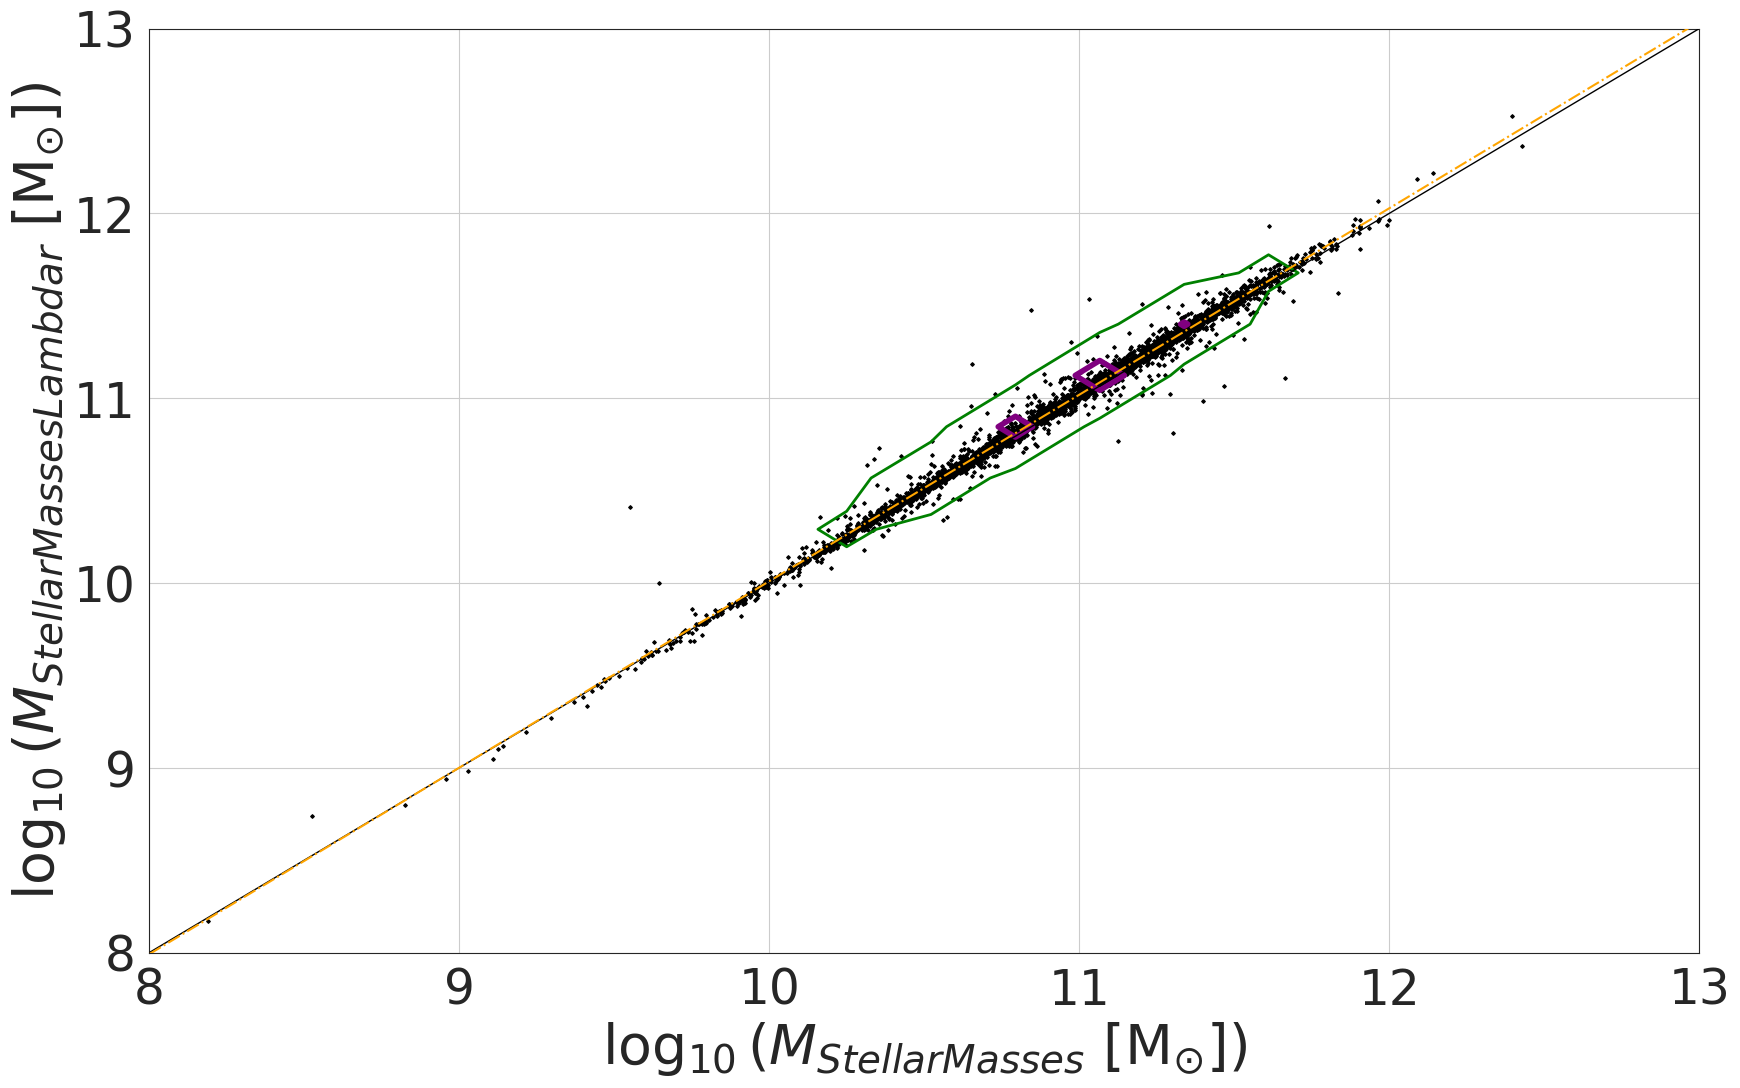

In [10]:
SM_SMLambdar = compare_plot_contour( data.log_gama_sm, data.log_gama_sm_lambdar, 
                                     '$M_{StellarMasses}$', '$M_{StellarMassesLambdar}$', fname = '../new_plots/SM_SMLambdar.pdf' )

Least square method
y = ( 0.9450013633729802 $\pm$ 0.004678687514324326 )*x +  0.4969505543204328 $\pm$ 0.051045550469651244
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -2669.422434820511
             x: [ 4.970e-01  9.450e-01  1.308e-01]
           nit: 165
          nfev: 299
 final_simplex: (array([[ 4.970e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01]]), array([-2.669e+03, -2.669e+03, -2.669e+03, -2.669e+03]))


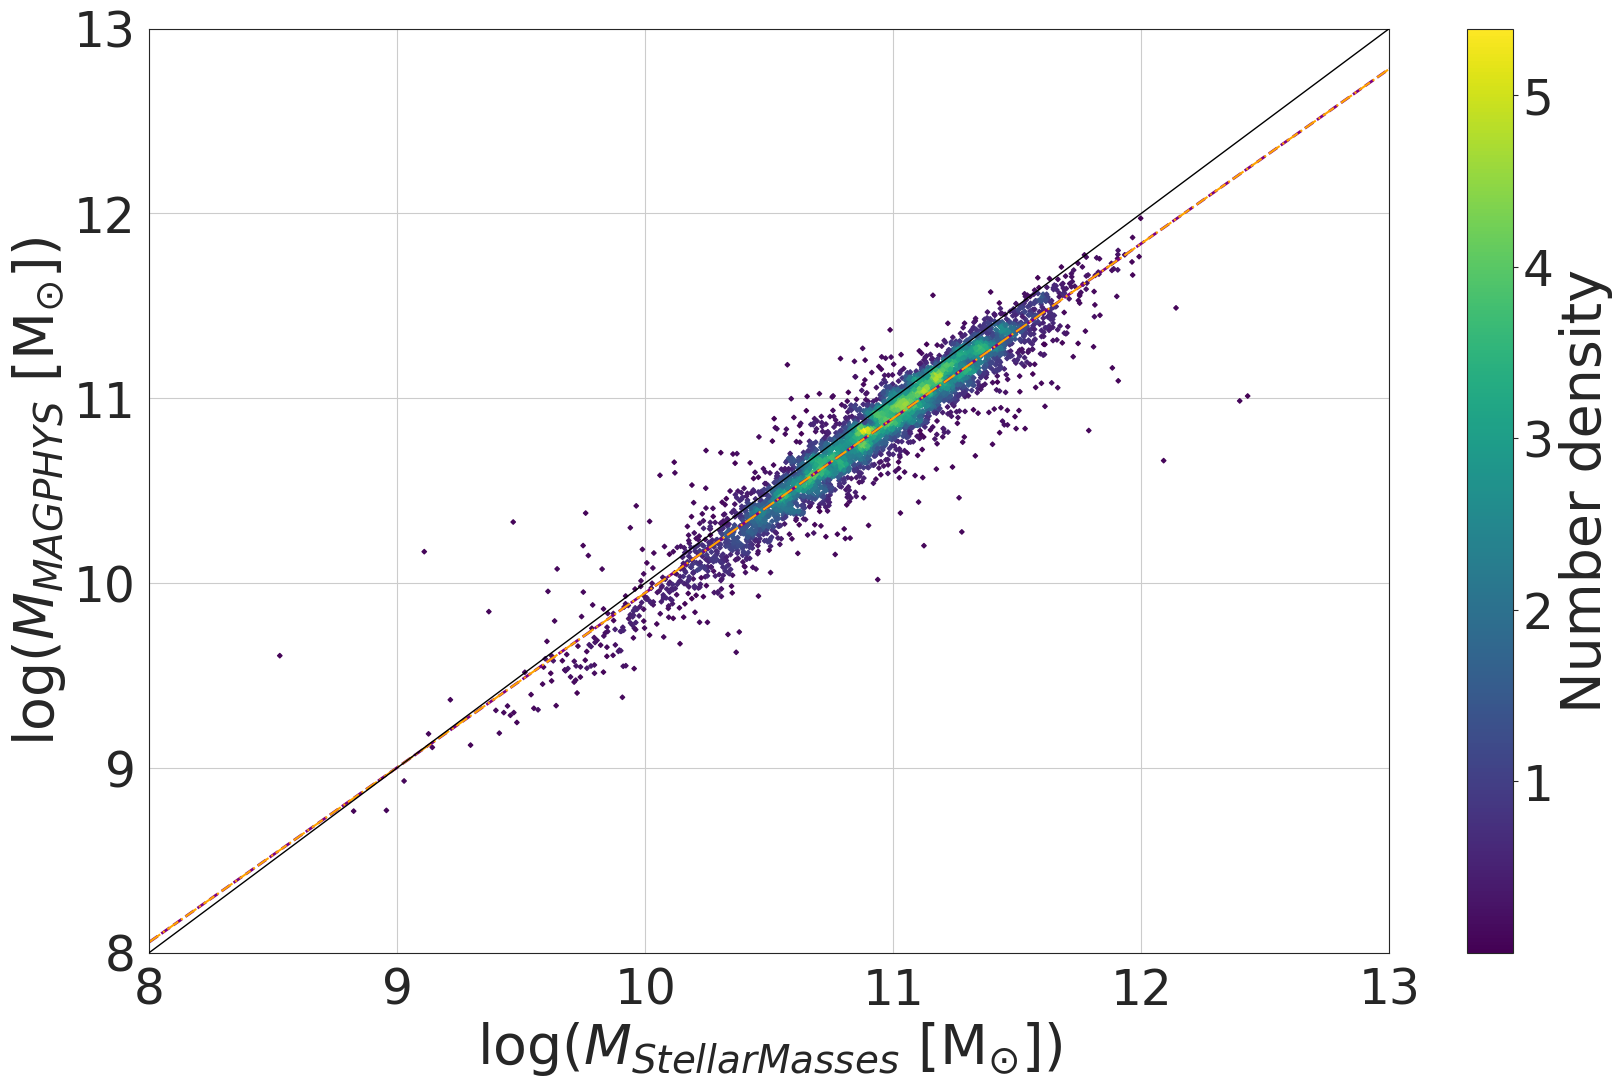

In [11]:
compare_plot( data.log_gama_sm, data.log_gama_sm_magphys, 
             '$M_{StellarMasses}$', '$M_{MAGPHYS}$' )

Least square method
y = ( 0.9450013633729802 $\pm$ 0.004678687514324326 )*x +  0.4969505543204328 $\pm$ 0.051045550469651244
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -2669.422434820511
             x: [ 4.970e-01  9.450e-01  1.308e-01]
           nit: 165
          nfev: 299
 final_simplex: (array([[ 4.970e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01],
                       [ 4.969e-01,  9.450e-01,  1.308e-01]]), array([-2.669e+03, -2.669e+03, -2.669e+03, -2.669e+03]))


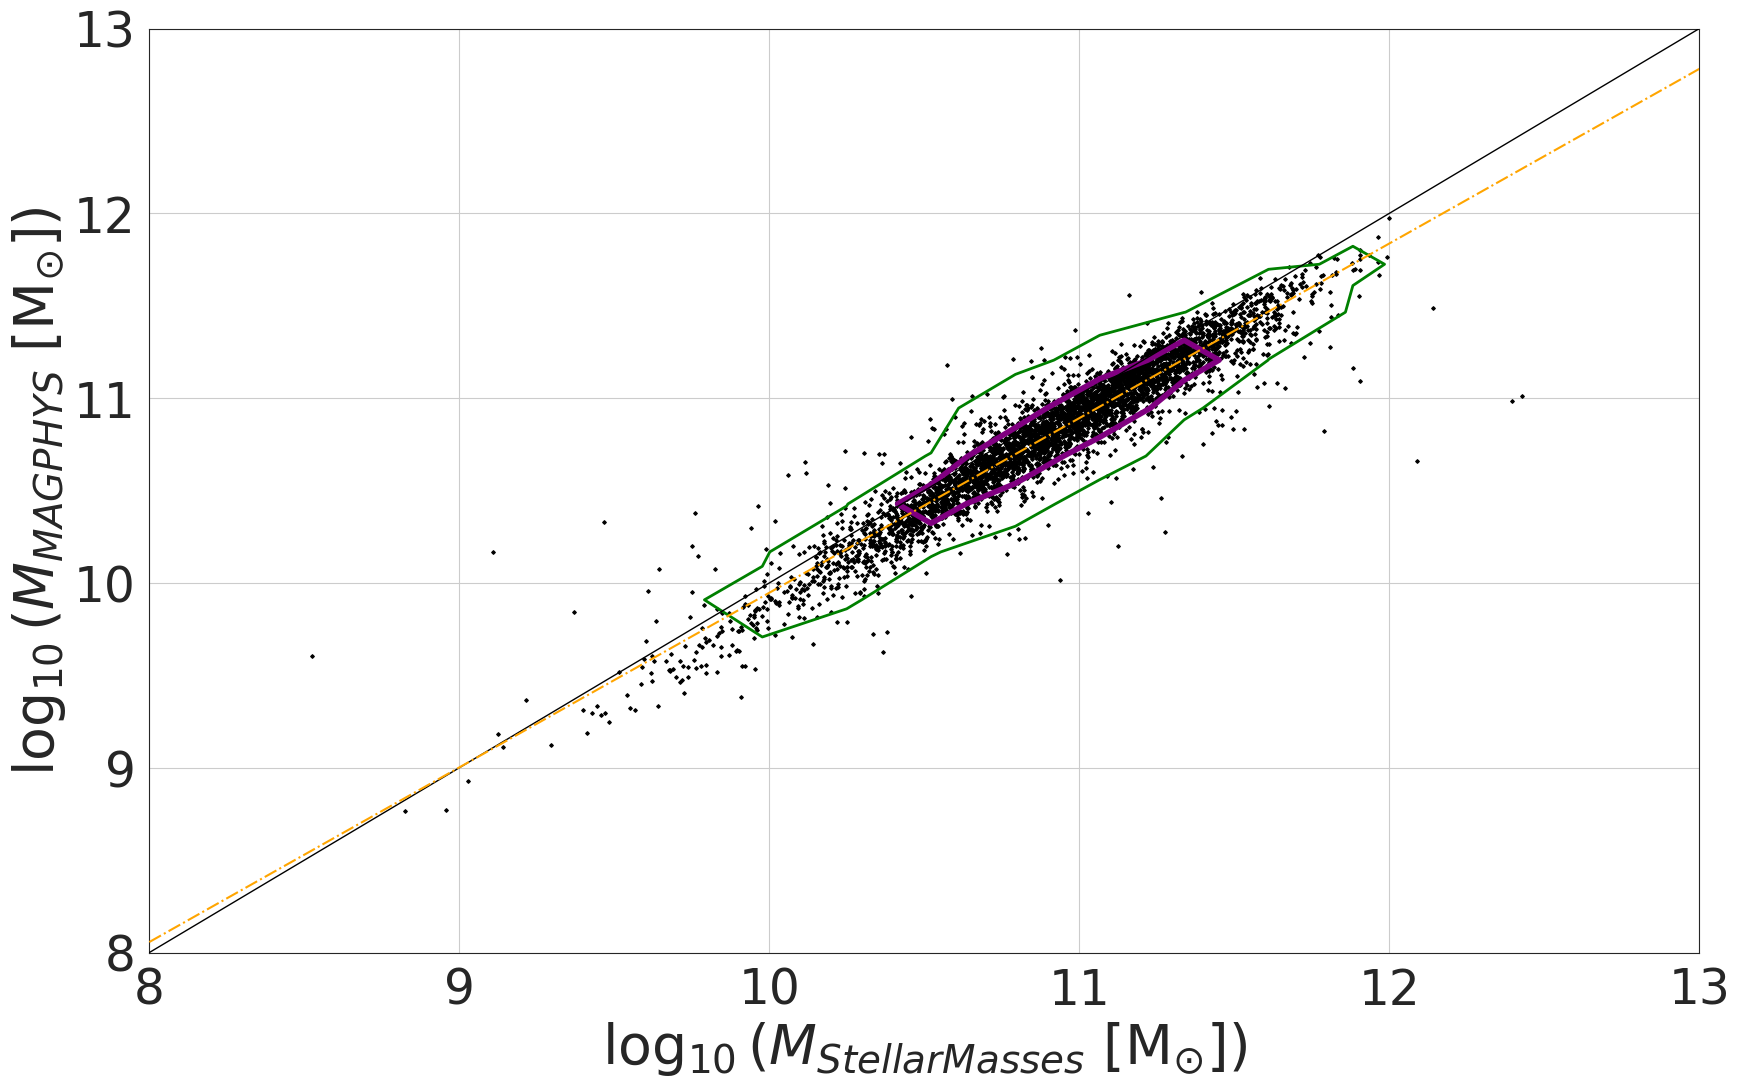

In [12]:
SM_Magphys = compare_plot_contour( data.log_gama_sm, data.log_gama_sm_magphys, 
                                    '$M_{StellarMasses}$', '$M_{MAGPHYS}$', fname = '../new_plots/SM_Magphys.pdf' )

Least square method
y = ( 0.9309749624970922 $\pm$ 0.004617740983002257 )*x +  0.6333091332897507 $\pm$ 0.05046380815876001
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -2662.194897538706
             x: [ 6.333e-01  9.310e-01  1.311e-01]
           nit: 152
          nfev: 265
 final_simplex: (array([[ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.332e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01]]), array([-2.662e+03, -2.662e+03, -2.662e+03, -2.662e+03]))


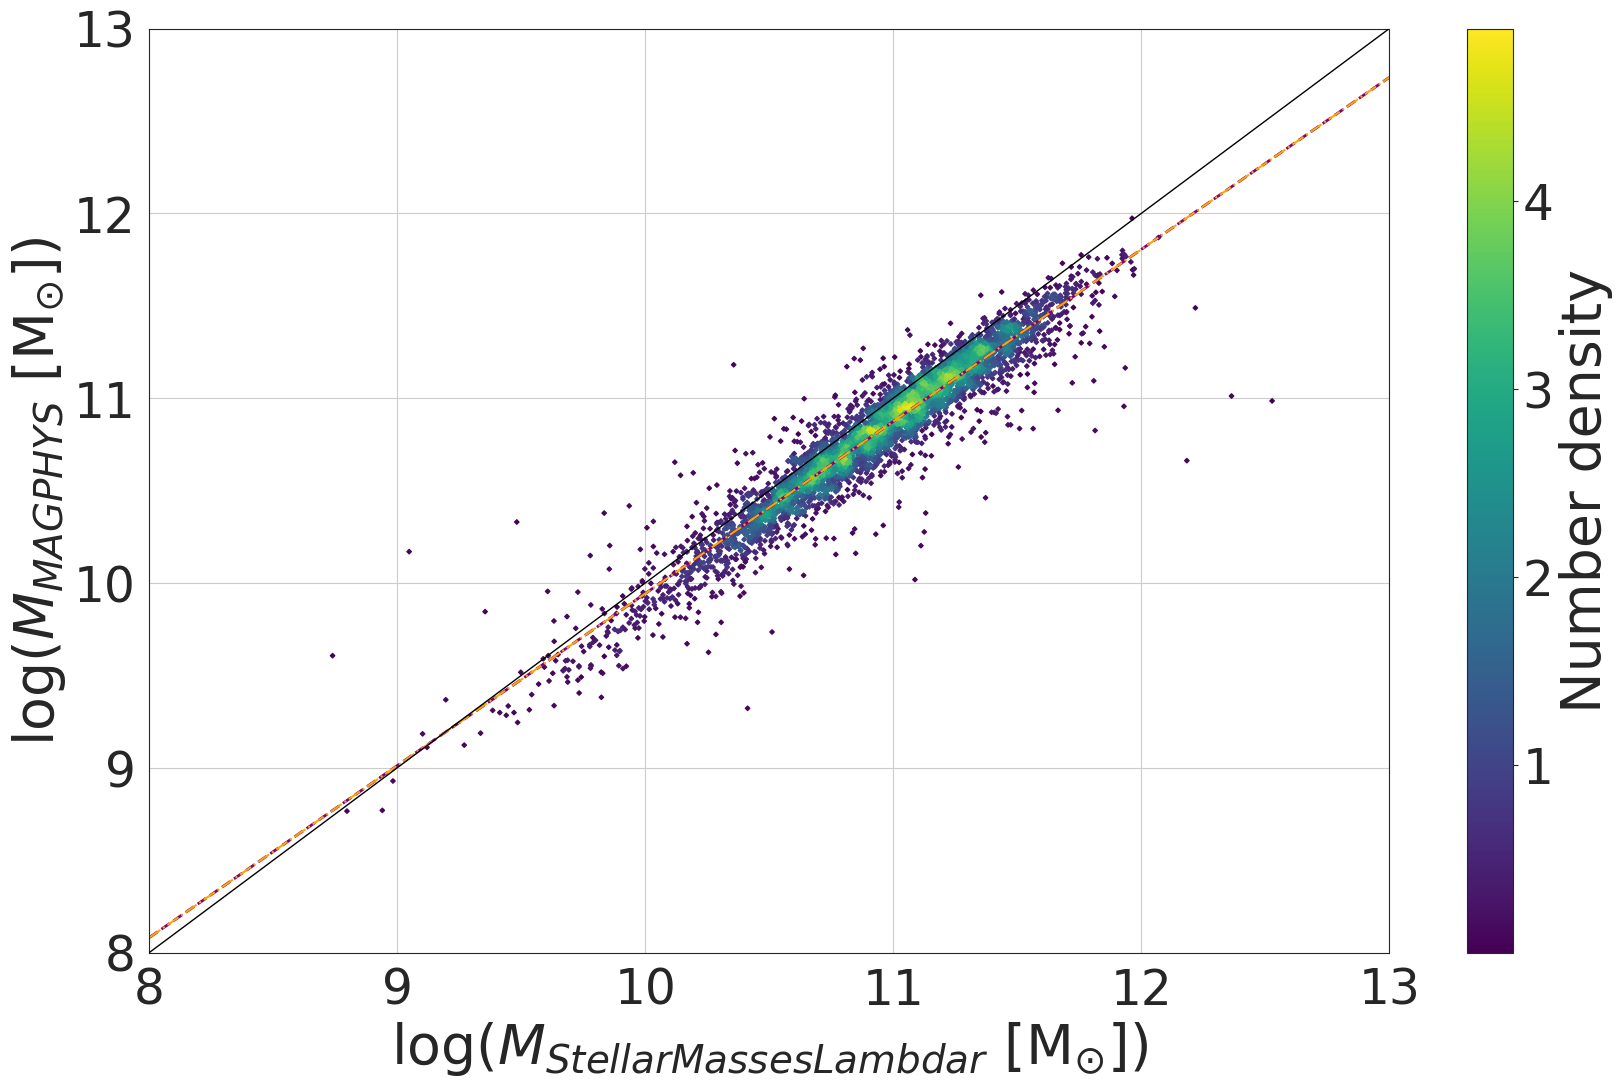

In [13]:
compare_plot( data.log_gama_sm_lambdar, data.log_gama_sm_magphys, 
             '$M_{StellarMassesLambdar}$', '$M_{MAGPHYS}$' )

Least square method
y = ( 0.9309749624970922 $\pm$ 0.004617740983002257 )*x +  0.6333091332897507 $\pm$ 0.05046380815876001
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -2662.194897538706
             x: [ 6.333e-01  9.310e-01  1.311e-01]
           nit: 152
          nfev: 265
 final_simplex: (array([[ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.332e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01]]), array([-2.662e+03, -2.662e+03, -2.662e+03, -2.662e+03]))


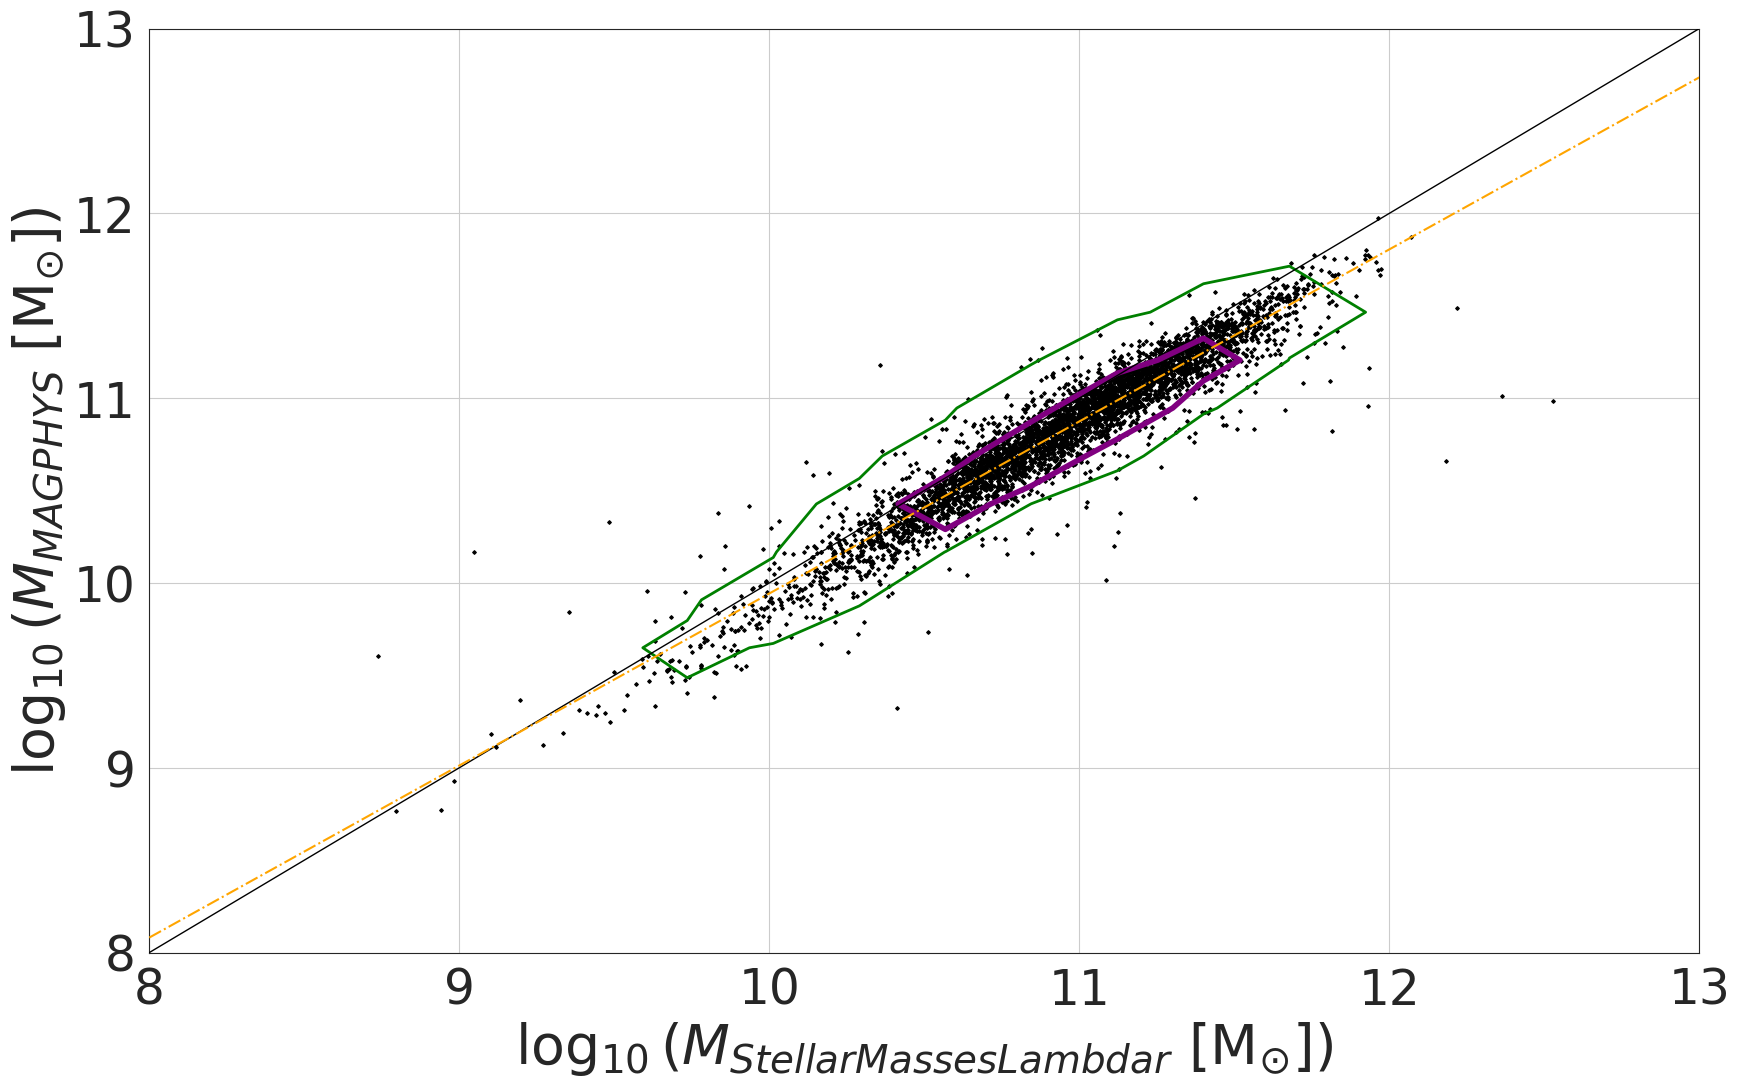

In [14]:
SMLambdar_Magphys = compare_plot_contour( data.log_gama_sm_lambdar, data.log_gama_sm_magphys, 
                                        '$M_{StellarMassesLambdar}$', '$M_{MAGPHYS}$', fname = '../new_plots/SMLambdar_Magphys.pdf' )

Least square method
y = ( 0.9309749624970922 $\pm$ 0.004617740983002257 )*x +  0.6333091332897507 $\pm$ 0.05046380815876001
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -2662.194897538706
             x: [ 6.333e-01  9.310e-01  1.311e-01]
           nit: 152
          nfev: 265
 final_simplex: (array([[ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.332e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01],
                       [ 6.333e-01,  9.310e-01,  1.311e-01]]), array([-2.662e+03, -2.662e+03, -2.662e+03, -2.662e+03]))


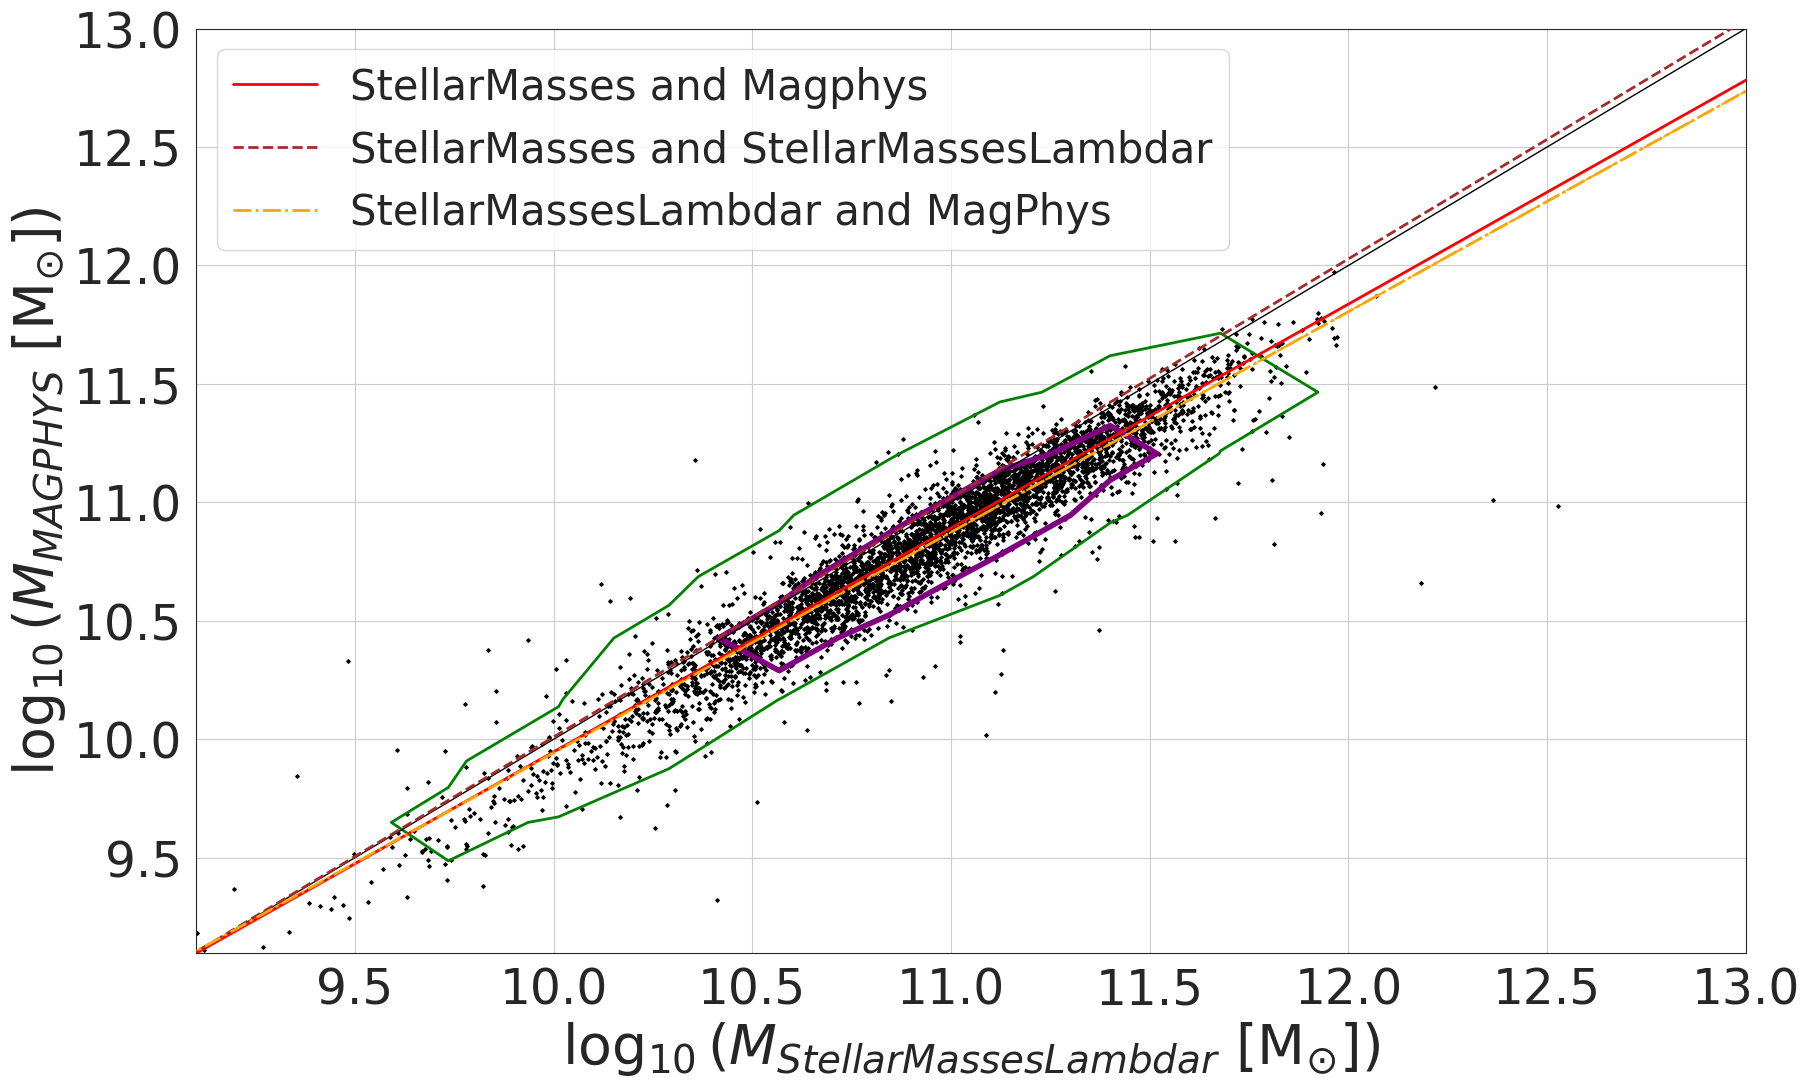

In [15]:
compare_plot_contour( data.log_gama_sm_lambdar, data.log_gama_sm_magphys, '$M_{StellarMassesLambdar}$', '$M_{MAGPHYS}$',
                      xmin = 9.1, xmax = 13 )
x = np.linspace( 8.5, 13, 100 )
plt.plot( x, SM_Magphys[1] * x + SM_Magphys[0], lw = 2, ls = '-',
         c = 'red', label = 'StellarMasses and Magphys', zorder = 50)
plt.plot( x, SM_SMLambdar[1] * x + SM_SMLambdar[0], lw = 2, ls = '--',
         c = 'brown', label = 'StellarMasses and StellarMassesLambdar',  zorder = 50)
plt.plot( x, SMLambdar_Magphys[1] * x + SMLambdar_Magphys[0], lw = 2, ls = '-.',
         c = 'orange', label = 'StellarMassesLambdar and MagPhys',  zorder = 50)
plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0, 1), fontsize = 30 )
plt.savefig( '../new_plots/all_fits_GAMA.pdf' , format = 'pdf' );